In [1]:

import pandas as pd
import matplotlib.pyplot
import sys
sys.path.insert(0, '../../Functions')
from plot_placement import plot_song_prediction_comparison_lstm, plot_xgboost_lstm_comparison
from lstm_model import build_and_evaluate_model, prepare_lstm_data, set_seed
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [4]:
data = pd.read_csv("../../Data/prepared_lstm_data.csv") # Load prepared data for LSTM model

In [3]:
configs = [
    {
        "name": "baseline",
        "lstm_units": [64],
        "dense_units": [32],
        "dropout_rate": 0.2
    },
    {
        "name": "two_lstm",
        "lstm_units": [64, 32],
        "dense_units": [32],
        "dropout_rate": 0.2
    },
    {
        "name": "two_lstm_two_dense",
        "lstm_units": [64, 32],
        "dense_units": [32, 16],
        "dropout_rate": 0.2
    }
]

seeds = [5, 10, 15, 20, 25] # Set of seeds for reproducibility
results = []

In [8]:
# Prepare sets of features for LSTM model
all_audio_features = ['Instrumentalness', 'Danceability', 'Acousticness',
                      'Duration_ms', 'Energy', 'Valence', 'Loudness',
                      'Speechiness', 'Key', 'Mode', 'Time_signature']

audio_features = ['Instrumentalness', 'Danceability', 'Acousticness', 'Duration_ms', 'Energy', 'Valence'] #The most important audio features based on feature importance analysis

all_features = ['Date', 'Song', 'Artist', 'Rank', 'Last Week', 'Weeks in Charts', 
                'Normalized Title', 'rank_change', 'rolling_avg_4_weeks', 'rolling_avg_all_time', 
                'rolling_std_4_weeks', 'rolling_std_all_time', 'target_next_rank'] + all_audio_features

features_max = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
    'rank_change',
    'rolling_avg_4_weeks',
    'rolling_avg_all_time',
    'rolling_std_4_weeks',
    'rolling_std_all_time'
] + all_audio_features


features_audio_selected = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
    'rank_change',
    'rolling_avg_4_weeks',
    'rolling_avg_all_time',
    'rolling_std_4_weeks',
    'rolling_std_all_time'
] + audio_features

features_min = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
]

features_rolling = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
    'rank_change',
    'rolling_avg_4_weeks',
    'rolling_avg_all_time',
    'rolling_std_4_weeks',
    'rolling_std_all_time'
] 

features_no_rolling = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
] + all_audio_features

In [5]:
ready_data = prepare_lstm_data(data, features=features_rolling)

In [ ]:
#test call the function to ensure it works
model, history, mae, rmse = build_and_evaluate_model(ready_data, seq_len=4, lstm_units=[64], dense_units=[32], dropout_rate=0.2, seed=42)
#looks like it works


Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 1.


In [6]:
for config in configs:
    for seed in seeds:
        set_seed(seed)
        print(f"Training model with config: {config['name']} and seed: {seed}")
        model, history, test_mae, test_rmse = build_and_evaluate_model(
            ready_data,
            seq_len=4,
            lstm_units=config["lstm_units"],
            dense_units=config["dense_units"],
            dropout_rate=config["dropout_rate"],
            seed=seed
        )
        
        results.append({
            "config": config["name"],
            "seed": seed,
            "test_mae": test_mae,
            "test_rmse": test_rmse
        })

Training model with config: baseline and seed: 5

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 9.
Training model with config: baseline and seed: 10

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 10.
Training model with config: baseline and seed: 15

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 11.
Training model with config: baseline and seed: 20

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



In [7]:
results_df = pd.DataFrame(results)

summary = (
    results_df
    .groupby("config")
    .agg(
        mean_mae=("test_mae", "mean"),
        std_mae=("test_mae", "std"),
        mean_rmse=("test_rmse", "mean"),
        std_rmse=("test_rmse", "std"),
        min_rmse=("test_rmse", "min"),
        max_rmse=("test_rmse", "max")
    )
    .sort_values("mean_rmse")
)

print(summary)

                    mean_mae   std_mae  mean_rmse  std_rmse  min_rmse  \
config                                                                  
baseline            4.694267  0.024468   7.249842  0.054371  7.167700   
two_lstm            4.882106  0.251878   7.259089  0.162047  7.098567   
two_lstm_two_dense  5.137314  0.470058   7.414481  0.296632  7.109012   

                    max_rmse  
config                        
baseline            7.318720  
two_lstm            7.477276  
two_lstm_two_dense  7.869782  


In [ ]:
#check baseline with different features sets
sets_to_test = {
    "features_max": features_max,
    "selected_audio_features": features_audio_selected,
    "features_min": features_min,
    "features_no_rolling": features_no_rolling,
}

for set_name, feature_set in sets_to_test.items():
    ready_data = prepare_lstm_data(data, features=feature_set)
    for seed in seeds:
        set_seed(seed)
        print(f"Training model with feature set: {set_name} and seed: {seed}")
        model, history, test_mae, test_rmse = build_and_evaluate_model(
            ready_data,
            seq_len=4,
            lstm_units=[64],
            dense_units=[32],
            dropout_rate=0.2,
            seed=seed
        )
        
        results.append({
            "config": set_name,
            "seed": seed,
            "test_mae": test_mae,
            "test_rmse": test_rmse
        })

Training model with feature set: features_max and seed: 5

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 16.
Training model with feature set: features_max and seed: 10

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 7.
Training model with feature set: features_max and seed: 15

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 6.
Training model with featu

In [11]:
# get results for the new feature sets
results2 = results[len(configs) * len(seeds):]  # Only keep the results from the new feature sets
results_df = pd.DataFrame(results2)

summary = (
    results_df
    .groupby("config")
    .agg(
        mean_mae=("test_mae", "mean"),
        std_mae=("test_mae", "std"),
        mean_rmse=("test_rmse", "mean"),
        std_rmse=("test_rmse", "std"),
        min_rmse=("test_rmse", "min"),
        max_rmse=("test_rmse", "max")
    )
    .sort_values("mean_rmse")
)

print(summary)

                         mean_mae   std_mae  mean_rmse  std_rmse  min_rmse  \
config                                                                       
features_min             4.770224  0.209533   7.277485  0.139119  7.154863   
features_max             4.757985  0.101492   7.309723  0.054427  7.239611   
features_no_rolling      4.793497  0.092953   7.363180  0.154887  7.230447   
selected_audio_features  4.953321  0.175262   7.413020  0.127882  7.257971   

                         max_rmse  
config                             
features_min             7.515902  
features_max             7.377755  
features_no_rolling      7.575065  
selected_audio_features  7.613140  


In [21]:
#save the best performing model (features_rolling) for future use and reference
#best model - baseline + rolling features
model, history, _, _ = build_and_evaluate_model(prepare_lstm_data(data, features=features_rolling),
                                                seq_len=4,
                                                lstm_units=[64],
                                                dense_units=[32],
                                                dropout_rate=0.2,
                                                seed=20)


Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 14.


In [22]:
import joblib
joblib.dump(model, "../Models/LSTM_improved.keras")

['../Models/LSTM_improved.keras']

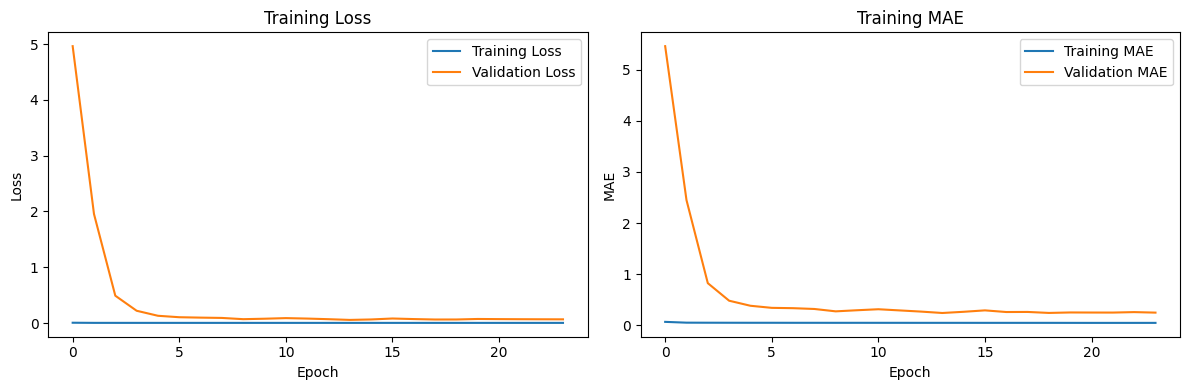

In [23]:
from matplotlib import pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()

plt.show()